In [44]:
import tensorflow as tf
print("Tensorflow version:", tf.__version__)
import numpy as np
import matplotlib.pyplot as plt
import os
import time

Tensorflow version: 2.7.0


In [45]:
#setting path
cwd = os.getcwd()
old_model_dir = os.path.join(cwd, 'model\\')
print(old_model_dir)


c:\Users\whylo\Desktop\MITA_Second_Year\NNDL\hw\hw2\model\


In [46]:
from keras.datasets import mnist
(X_train,y_train),(X_test,y_test)=mnist.load_data()
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

from tensorflow.keras.utils import to_categorical
y_train01=to_categorical(y_train)
y_test01=to_categorical(y_test)

In [47]:
import keras
from sklearn.metrics import confusion_matrix, accuracy_score
# clone the network learned above into nn and set its weight:
nn = tf.keras.models.load_model(old_model_dir)
nn2=keras.models.Sequential(nn.layers[:-1])
# Add a new dense output layer:
nn2.add(keras.layers.Dense(10,activation='softmax'))
# Make all layers except the new output layer untrainable, that is fixed.
for layer in nn2.layers[:-1]:
    layer.trainable=False
nn2.compile(optimizer='nadam',loss='categorical_crossentropy',metrics=['accuracy'])

X_train = X_train.reshape(np.shape(X_train)[0],28*28)
X_test = X_test.reshape(np.shape(X_test)[0],28*28)

history=nn2.fit(X_train, y_train01, epochs=20, batch_size=128)
# predict on the test digits and plot the confusiton matrix and print the accuracy rate:




Epoch 1/20
469/469 [==============================] - 3s 6ms/step - loss: 1.3479 - accuracy: 0.5186
Epoch 2/20
469/469 [==============================] - 3s 6ms/step - loss: 1.1266 - accuracy: 0.5794
Epoch 3/20
469/469 [==============================] - 3s 6ms/step - loss: 1.0934 - accuracy: 0.5892
Epoch 4/20
469/469 [==============================] - 3s 6ms/step - loss: 1.0777 - accuracy: 0.5899
Epoch 5/20
469/469 [==============================] - 3s 6ms/step - loss: 1.0672 - accuracy: 0.5938
Epoch 6/20
469/469 [==============================] - 3s 6ms/step - loss: 1.0653 - accuracy: 0.5922
Epoch 7/20
469/469 [==============================] - 3s 6ms/step - loss: 1.0565 - accuracy: 0.5961
Epoch 8/20
469/469 [==============================] - 3s 6ms/step - loss: 1.0506 - accuracy: 0.5994
Epoch 9/20
469/469 [==============================] - 3s 6ms/step - loss: 1.0485 - accuracy: 0.6013
Epoch 10/20
469/469 [==============================] - 3s 6ms/step - loss: 1.0502 - accuracy: 0.5998

Accuracy achived: 0.677
[[742  12  44  72  32   6  82   0   9   1]
 [ 13 888  16  52  12   0  19   0   0   0]
 [ 39   3 730   6 154   1  52   0  14   1]
 [172 113  13 604  45   1  50   0   2   0]
 [ 69  10 455  32 388   5  36   0   4   1]
 [  0   3   0   7   0 707   1 207  16  59]
 [224  13 362  26 202   6 156   0  11   0]
 [  0   0   0   0   0  22   0 866   4 108]
 [  3   3  86   4  67  11  17  13 791   5]
 [  1   0   2   2   1  14   1  77   4 898]]


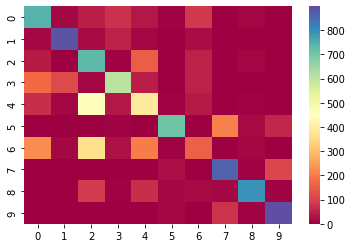

In [52]:
predDigits=nn2.predict(X_test)
C=confusion_matrix(y_test, list(map(np.argmax,predDigits)))
print("Accuracy achived:",accuracy_score(y_test,list(map(np.argmax,predDigits))))
import seaborn as sns
sns.heatmap(C,cmap="Spectral")
print(C)
names=["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]